In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Tesla.csv - Tesla.csv.csv to Tesla.csv - Tesla.csv.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("Tesla.csv - Tesla.csv.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2010-06-29,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,2010-06-30,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,2010-07-01,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,2010-07-02,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,2010-07-06,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [ ]:
df['Price_Range'] = df['High'] - df['Low']
df['Avg_Price'] = (df['Open'] + df['Close'])/2

X = df[['Open','High','Low','Volume','Price_Range','Avg_Price']]
y = df['Close']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [ ]:
print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression
MSE: 9.224182677671096e-26
MAE: 1.6729194234422535e-13
R2: 1.0


In [ ]:
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)

In [ ]:
print("Support Vector Regression")
print("MSE:", mean_squared_error(y_test, y_pred_svr))
print("MAE:", mean_absolute_error(y_test, y_pred_svr))
print("R2:", r2_score(y_test, y_pred_svr))

Support Vector Regression
MSE: 1.6643886010255207
MAE: 0.7215148461419959
R2: 0.9998215302475697


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
print("Random Forest Regression")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest Regression
MSE: 3.275067434328349
MAE: 1.0523418380531044
R2: 0.999648819708428


In [ ]:
compare = pd.DataFrame({
    "Actual": y_test.values,
    "Linear_Pred": y_pred_lr,
    "SVR_Pred": y_pred_svr,
    "RF_Pred": y_pred_rf
})

compare.head()

,Actual,Linear_Pred,SVR_Pred,RF_Pred
0,203.990005,203.990005,203.379028,202.747303
1,219.740005,219.740005,219.834500,219.581900
2,226.050003,226.050003,227.158051,228.001999
3,197.330002,197.330002,197.624729,198.475399
4,227.070007,227.070007,226.510533,225.334700


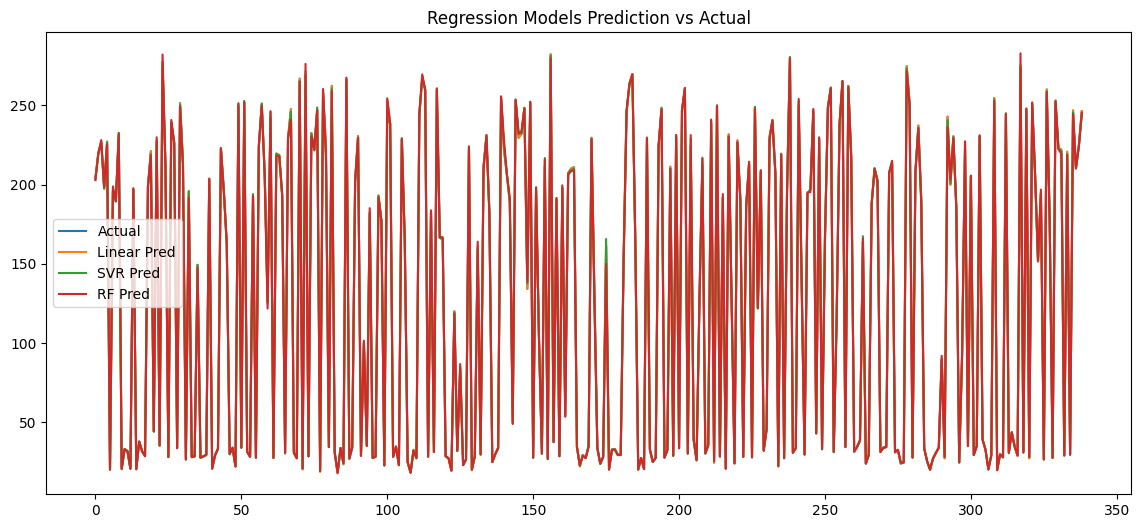

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lr, label="Linear Pred")
plt.plot(y_pred_svr, label="SVR Pred")
plt.plot(y_pred_rf, label="RF Pred")
plt.legend()
plt.title("Regression Models Prediction vs Actual")
plt.show()